# Байесовский Классификатор

In [1]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


Дано множество M из 21 образов.
Задан порог кластеризации T1 = 2.5

=== ШАГ 1: Последовательная кластеризация (BSAS) ===
Инициализация: первая точка x_1 = [5.28, 5.26] становится центром первого кластера z_1.
  Точка 7 [15.20, 4.88] удалена от всех центров больше чем на T1. Создан новый кластер z_2 = [15.2   4.88]
  Точка 14 [-1.62, -0.32] удалена от всех центров больше чем на T1. Создан новый кластер z_3 = [-1.62 -0.32]

Кластеризация BSAS завершена. Сформировано 3 классов.

=== ШАГ 2: Расчет параметров для каждого класса ===

Класс w_1:
  Элементы: [[np.float64(5.28), np.float64(5.26)], [np.float64(6.09), np.float64(5.83)], [np.float64(5.81), np.float64(5.86)], [np.float64(6.14), np.float64(5.8)], [np.float64(5.73), np.float64(6.17)], [np.float64(5.53), np.float64(5.5)]]
  Количество точек N_1 = 6
  Априорная вероятность P = 0.2857
  Центроид m_1 = [5.7633, 5.7367]
  Матрица ковариации C_1:
    [0.0900, 0.0552]
    [0.0552, 0.0832]

Класс w_2:
  Элементы: [[np.float64(15.2), np.float

Введите координату X для новой точки (или нажмите Enter для X=0.0):  
Введите координату Y для новой точки (или нажмите Enter для Y=0.0):  



Значения дискриминантных функций QDA для точки [0.0, 0.0]:
  D_1 = -232.2353
  D_2 = -802.1043
  D_3 = 0.3508

Новая точка [0.0, 0.0] отнесена к классу w_3

=== ШАГ 4: Расчет разделяющих границ классов ===
Сканирование сетки для поиска границ...
Расчет завершен. Найдено точек границы: 1609

Построение графиков...


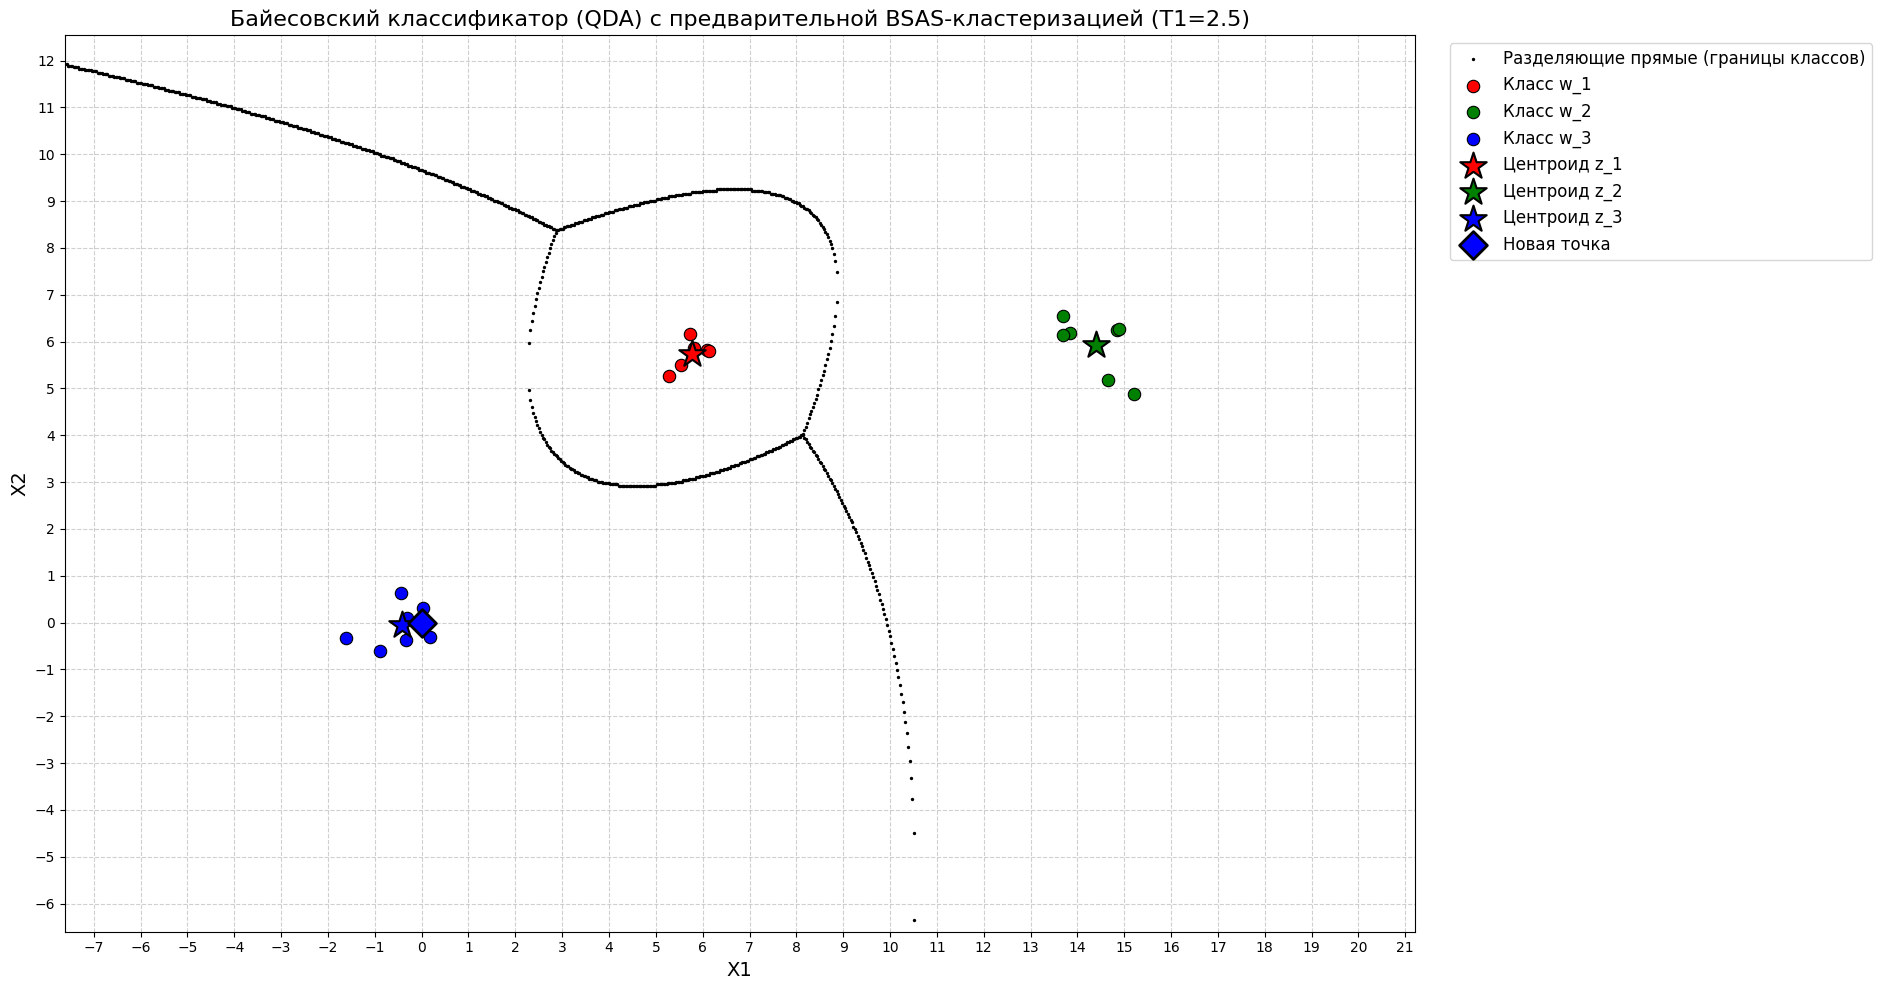

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Шаг сетки для поиска границ
e = 0.03

# Порог T1 изменен до 2.5 во избежание образования кластеров из 1 точки
T1 = 2.5

# Новые координаты точек
x = np.array([5.28, 6.09, 5.81, 6.14, 5.73, 5.53, 15.20, 13.70, 14.84, 13.85, 14.88, 13.70, 14.66, -1.62, 0.03, 0.18, -0.89, 0.00, -0.32, -0.33, -0.45])
y = np.array([5.26, 5.83, 5.86, 5.80, 6.17, 5.50,  4.88,  6.55,  6.25,  6.18,  6.26,  6.15,  5.17, -0.32, 0.31, -0.31, -0.60, 0.12,  0.09, -0.37,  0.63])

numo = len(x)

print(f"Дано множество M из {numo} образов.")
print(f"Задан порог кластеризации T1 = {T1}")

# Функция вычисления евклидова расстояния
def dist(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# --- ЭТАП 1: Последовательная кластеризация (BSAS) ---
print("\n=== ШАГ 1: Последовательная кластеризация (BSAS) ===")

r = 0
mju = r
V = [r]
klas = []
z1 = np.array([x[r], y[r]])

print(f"Инициализация: первая точка x_1 = [{x[0]:.2f}, {y[0]:.2f}] становится центром первого кластера z_1.")

i = 0
while i < numo:
    if i != mju:
        d_z = dist(z1[0], z1[1], x[i], y[i])
        if d_z < T1:
            pass  # Точка поглощается текущим активным представителем
        else:
            j = 0
            k = 0
            while j < len(V):
                d_v = dist(x[i], y[i], x[V[j]], y[V[j]])
                if d_v > T1:
                    k += 1
                else:
                    z1 = np.array([x[V[j]], y[V[j]]])
                    r = V[j]
                j += 1
            if k == len(V):
                r = i
                z1 = np.array([x[i], y[i]])
                V.append(i)
                print(f"  Точка {i+1} [{x[i]:.2f}, {y[i]:.2f}] удалена от всех центров больше чем на T1. Создан новый кластер z_{len(V)} = {z1}")
    klas.append(V.index(r) + 1)
    i += 1

klas = np.array(klas)
max_class = max(klas)

print(f"\nКластеризация BSAS завершена. Сформировано {max_class} классов.")

# --- ЭТАП 2: Расчет параметров для каждого класса ---
print("\n=== ШАГ 2: Расчет параметров для каждого класса ===")

mX = np.zeros(max_class)
mY = np.zeros(max_class)
num = np.zeros(max_class)

# Суммирование координат для вычисления средних значений (центроидов)
for i in range(len(klas)):
    c_idx = klas[i] - 1
    mX[c_idx] += x[i]
    mY[c_idx] += y[i]
    num[c_idx] += 1

mX /= num
mY /= num

# Формирование элементов ковариационных матриц
X_mat = np.zeros((2, 1))
mxxt = np.zeros((max_class, 4))

for i in range(len(klas)):
    c_idx = klas[i] - 1
    X_mat[0, 0] = x[i]
    X_mat[1, 0] = y[i]
    Xc = np.dot(X_mat, X_mat.T)
    mxxt[c_idx, 0] += Xc[0, 0]
    mxxt[c_idx, 1] += Xc[0, 1]
    mxxt[c_idx, 2] += Xc[1, 0]
    mxxt[c_idx, 3] += Xc[1, 1]

for i in range(max_class):
    mxxt[i, :] /= num[i]

# Априорные вероятности классов
P = np.zeros(max_class)
for i in range(len(klas)):
    c_idx = klas[i] - 1
    P[c_idx] += 1
P /= numo

# Вспомогательная функция для расчета дискриминанты Байеса (QDA)
def compute_D(pt_x, pt_y, class_idx):
    mx = np.zeros((2, 2))
    mx[0, 0] = mxxt[class_idx, 0]
    mx[0, 1] = mxxt[class_idx, 1]
    mx[1, 0] = mxxt[class_idx, 2]
    mx[1, 1] = mxxt[class_idx, 3]
    
    m = np.array([[mX[class_idx]], [mY[class_idx]]])
    C = mx - np.dot(m, m.T)  # Формула C = E[XX^T] - m * m^T
    
    det_C = np.linalg.det(C)
    inv_C = np.linalg.inv(C)
    
    X_vec = np.array([[pt_x], [pt_y]])
    diff = X_vec - m
    mahalanobis_term = np.dot(diff.T, np.dot(inv_C, diff))[0, 0]
    
    # Квадратичная дискриминантная функция (логарифм апостериорной вероятности)
    D = np.log(P[class_idx]) - 0.5 * np.log(det_C) - 0.5 * mahalanobis_term
    return D, C

# Вывод параметров по каждому классу
for i in range(max_class):
    class_points = [[round(x[j], 2), round(y[j], 2)] for j in range(numo) if klas[j] == i + 1]
    print(f"\nКласс w_{i+1}:")
    print(f"  Элементы: {class_points}")
    print(f"  Количество точек N_{i+1} = {int(num[i])}")
    print(f"  Априорная вероятность P = {P[i]:.4f}")
    print(f"  Центроид m_{i+1} = [{mX[i]:.4f}, {mY[i]:.4f}]")
    
    # Получение и вывод матрицы ковариации
    _, C_val = compute_D(0, 0, i)
    print(f"  Матрица ковариации C_{i+1}:")
    print(f"    [{C_val[0, 0]:.4f}, {C_val[0, 1]:.4f}]")
    print(f"    [{C_val[1, 0]:.4f}, {C_val[1, 1]:.4f}]")

# --- ЭТАП 3: Классификация тестовой точки ---
print("\n=== ШАГ 3: Классификация новой точки ===")
try:
    px_input = input("Введите координату X для новой точки (или нажмите Enter для X=0.0): ")
    py_input = input("Введите координату Y для новой точки (или нажмите Enter для Y=0.0): ")
    px = float(px_input.replace(',', '.')) if px_input else 0.0
    py = float(py_input.replace(',', '.')) if py_input else 0.0
    new_point = [px, py]
except ValueError:
    new_point = [0.0, 0.0]
    print("Некорректный ввод. Установлена точка по умолчанию: [0.0, 0.0]")

D_test = np.zeros(max_class)

print(f"\nЗначения дискриминантных функций QDA для точки {new_point}:")
for i in range(max_class):
    D_val, _ = compute_D(new_point[0], new_point[1], i)
    D_test[i] = D_val
    print(f"  D_{i+1} = {D_val:.4f}")

colpr = np.argmax(D_test) + 1
print(f"\nНовая точка {new_point} отнесена к классу w_{colpr}")

# --- ЭТАП 4: Построение разделяющих границ ---
print("\n=== ШАГ 4: Расчет разделяющих границ классов ===")
print("Сканирование сетки для поиска границ...")

# Расчет динамических границ отрисовки и сетки на основе данных и новой точки
x_min = min(np.min(x), new_point[0]) - 6
x_max = max(np.max(x), new_point[0]) + 6
y_min = min(np.min(y), new_point[1]) - 6
y_max = max(np.max(y), new_point[1]) + 6

# Сетка поиска выходит за видимые пределы для корректного отображения краев
x_grid_min, x_grid_max = x_min - 2, x_max + 2
y_grid_min, y_grid_max = y_min - 2, y_max + 2

boundary_x = []
boundary_y = []

cur_x = x_grid_min
colcur = 0

while cur_x < x_grid_max:
    cur_y = y_grid_min
    while cur_y < y_grid_max:
        D_grid = np.zeros(max_class)
        for i in range(max_class):
            D_grid[i], _ = compute_D(cur_x, cur_y, i)
        colpr_grid = np.argmax(D_grid) + 1
        
        # Фиксация границы в месте смены класса
        if colpr_grid != colcur:
            boundary_x.append(cur_x)
            boundary_y.append(cur_y)
        colcur = colpr_grid
        cur_y += e
    cur_x += e

print(f"Расчет завершен. Найдено точек границы: {len(boundary_x)}")

# --- ЭТАП 5: Визуализация ---
print("\nПостроение графиков...")

plt.figure(figsize=(18, 10))
plt.title(f"Байесовский классификатор (QDA) с предварительной BSAS-кластеризацией (T1={T1})", fontsize=16)
plt.axis('scaled')

# Оригинальные цвета из первого кода
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'pink', 'brown', 'gray', 'olive',
          'deepskyblue', 'greenyellow', 'yellowgreen', 'gold', 'lightcoral', 'lightsalmon']

# Установка целочисленного шага сетки осей как в первом коде
x_ticks = np.arange(math.floor(x_min), math.ceil(x_max) + 1, 1)
y_ticks = np.arange(math.floor(y_min), math.ceil(y_max) + 1, 1)
plt.xticks(x_ticks)
plt.yticks(y_ticks)

# Отрисовка разделяющих границ
if len(boundary_x) > 0:
    plt.scatter(boundary_x, boundary_y, c='black', s=2, label='Разделяющие прямые (границы классов)', zorder=2)

# Отрисовка точек классов (круги с обводкой)
for i in range(max_class):
    class_mask = (klas == i + 1)
    if np.any(class_mask):
        plt.scatter(x[class_mask], y[class_mask], c=colors[i % len(colors)], label=f'Класс w_{i+1}',
                    edgecolors='black', linewidths=0.8, s=80, zorder=3)

# Отрисовка центроидов классов (крупные звезды с обводкой)
for i in range(max_class):
    plt.scatter(mX[i], mY[i], c=colors[i % len(colors)], marker='*', s=400,
                edgecolors='black', linewidths=1.5, zorder=4, label=f'Центроид z_{i+1}')

# Отрисовка тестируемой точки (крупный ромб)
new_point_class_idx = colpr - 1
plt.scatter(new_point[0], new_point[1], c=colors[new_point_class_idx % len(colors)], marker='D', s=200,
            edgecolors='black', linewidths=2, zorder=5, label='Новая точка')

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("X1", fontsize=14)
plt.ylabel("X2", fontsize=14)

# Границы отображения осей
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Формирование легенды без дублирующихся элементов
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=12)

plt.tight_layout()
plt.show()